[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Projects/project_3_weekly/project_3_starter.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Project 3 — Can you predict the market?
## Starter: honest evaluation of a weekly direction rule on the S&P 500, 1990–2010

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

Read `README.md` in this folder first — it states the decision you are being asked to make and the numbers your memo must contain.

**Goal.** Decide whether next week's market direction can be predicted from the previous weeks' returns; estimate the accuracy of your rule *honestly* on a held-out period; attach a 95 % interval to it; and tell a fund what to do.

This notebook gives you the data, the held-out split, the baseline and the scoring helper. Everything from **Step 1** onwards is yours.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

ISLP not installed; using CSV / URL fallbacks.


## 1. First look at the data

`Weekly` holds 1,089 consecutive weeks of S&P 500 returns, 1990 through 2010. `Lag1`–`Lag5` are the previous five weeks' percentage returns, `Volume` is the average daily share volume that week (in billions), `Today` is this week's return and `Direction` is its sign.

In [2]:
Weekly = load('Weekly')

print('shape:', Weekly.shape)
print('columns:', list(Weekly.columns))
print('years:', Weekly['Year'].min(), '-', Weekly['Year'].max())
Weekly.head()

shape: (1089, 9)
columns: ['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction']
years: 1990 - 2010


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [3]:
# The target, and how unbalanced it is over the whole series.
print(Weekly['Direction'].value_counts().to_string())
print()
print(f"'Up' is the majority class: {(Weekly['Direction'] == 'Up').mean():.1%} of all 1,089 weeks.")
print('So a rule that says "Up" every single week is already right more often than a coin.')

Direction
Up      605
Down    484

'Up' is the majority class: 55.6% of all 1,089 weeks.
So a rule that says "Up" every single week is already right more often than a coin.


### The one fact that shapes this problem

The rows of `Weekly` are **not** 1,089 interchangeable draws from a population. They are a **series**: row 0 is the first week of 1990, row 1088 is the last week of 2010, and the market of 1990 is not the market of 2010. Two pictures make the point.

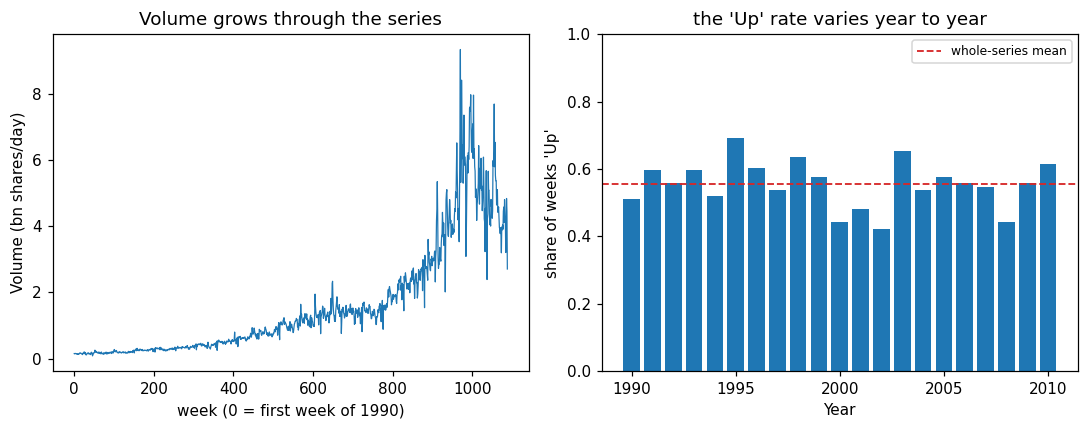

corr(Volume, Year) = 0.842
Volume mean by half-decade (bn shares/day):
Year
1990    0.219
1995    0.550
2000    1.296
2005    3.607
2010    4.558


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Volume is not stationary -- it grows by a factor of ~20 across the series.
axes[0].plot(Weekly.index, Weekly['Volume'], color='C0', lw=0.8)
axes[0].set(xlabel='week (0 = first week of 1990)', ylabel='Volume (bn shares/day)',
            title='Volume grows through the series')

# (b) The share of 'Up' weeks is itself unstable from year to year.
up_rate = Weekly.groupby('Year')['Direction'].apply(lambda s: (s == 'Up').mean())
axes[1].bar(up_rate.index, up_rate.values, color='C0')
axes[1].axhline((Weekly['Direction'] == 'Up').mean(), color='C3', lw=1.2, ls='--',
                label='whole-series mean')
axes[1].set(xlabel='Year', ylabel="share of weeks 'Up'", ylim=(0, 1),
            title="the 'Up' rate varies year to year")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"corr(Volume, Year) = {np.corrcoef(Weekly['Year'], Weekly['Volume'])[0, 1]:.3f}")
print('Volume mean by half-decade (bn shares/day):')
print(Weekly.groupby(Weekly['Year'] // 5 * 5)['Volume'].mean().round(3).to_string())

**Reading the pictures.** `Volume` in 2009 is an order of magnitude larger than in 1990, and the `Up` rate swings from year to year. The arrangement of the rows in time therefore carries information, and any procedure that ignores that arrangement is making an assumption about this series that these two panels do not support. Keep that in mind when you reach requirement 5 of the brief.

## 2. The predictors — and the two columns you may never use

`Direction` is by construction the sign of `Today`. Handing a classifier `Today` therefore hands it the answer: it will score near 100 %, and the number will mean nothing. The guard below is called for you by the scoring helper in Step&nbsp;4, so a leaked design matrix raises instead of quietly scoring 99 %.

In [5]:
PREDICTORS = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']   # the ONLY candidates
FORBIDDEN  = {'Today', 'Direction'}                               # the answer, in two forms

def check_predictors(cols):
    """Raise if a design matrix contains the answer; return cols unchanged."""
    cols = list(cols)
    leaked = FORBIDDEN.intersection(cols)
    if leaked:
        raise ValueError(
            f"Leakage: {sorted(leaked)} may never be a predictor of 'Direction' -- "
            "'Direction' IS the sign of 'Today'. Use only Lag1-Lag5 and Volume.")
    unknown = set(cols) - set(PREDICTORS)
    if unknown:
        raise ValueError(f'Not a candidate predictor: {sorted(unknown)}')
    return cols

print('candidate predictors:', check_predictors(PREDICTORS))
try:
    check_predictors(['Lag2', 'Today'])
except ValueError as err:
    print('guard works ->', err)

candidate predictors: ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
guard works -> Leakage: ['Today'] may never be a predictor of 'Direction' -- 'Direction' IS the sign of 'Today'. Use only Lag1-Lag5 and Volume.


## 3. The held-out split — fixed, and not to be touched until the end

Everyone in the course uses the **same** split, so that everyone's final number is comparable:

- **training years:** `Year <= 2008` — 985 weeks, yours to explore, plot, fit and refit as much as you like;
- **held-out period:** **2009–2010** — 104 weeks, which you touch **once**, at the very end, through `evaluate()`.

Note what the split is *not*: it is not a random sample of rows. `SEED = 2024` below seeds your *models* (`random_state=SEED`), not the split. For a series, the honest question is "having seen the past, how well would this rule have done next?", and only a cut in time answers it. A split that scattered the 104 held-out weeks at random across 1990–2010 would answer a different and much easier question.

In [6]:
SEED = 2024          # seed every model with this: random_state=SEED
TRAIN_END = 2008     # the cut in time

y = (Weekly['Direction'] == 'Up').astype(int)           # 1 = Up, 0 = Down
train = Weekly['Year'] <= TRAIN_END
test  = ~train                                          # 2009-2010: hands off until the end

X_train, y_train = Weekly.loc[train, PREDICTORS], y[train]
X_test,  y_test  = Weekly.loc[test,  PREDICTORS], y[test]

print(f'train: n = {train.sum():4d}   years {Weekly.loc[train, "Year"].min()}-{Weekly.loc[train, "Year"].max()}')
print(f'test : n = {test.sum():4d}   years {Weekly.loc[test,  "Year"].min()}-{Weekly.loc[test,  "Year"].max()}')
print()
print(f"'Up' rate in the training years : {y_train.mean():.1%}")
print(f"'Up' rate in the held-out period: {y_test.mean():.1%}")

train: n =  985   years 1990-2008
test : n =  104   years 2009-2010

'Up' rate in the training years : 55.2%
'Up' rate in the held-out period: 58.7%


## 4. The baseline you have to beat, and the helper that scores you

**The baseline.** Predict `Up` every week. It uses no data and cannot be beaten by accident. Its accuracy on the held-out period is simply the share of `Up` weeks there — which is *higher* than the whole-series share, one reason why 50 % is the wrong yardstick.

**The interval.** With 104 held-out weeks, an accuracy is a proportion estimated from 104 Bernoulli trials: a standard error of about $\sqrt{0.25/104} \approx 4.9$ percentage points, so a 95 % interval reaching roughly **±9.6 points either side** of whatever you observe. `evaluate()` computes that interval for you and reports whether it contains the baseline, because on a sample this size *an accuracy without an interval is not a result*.

In [7]:
from scipy.stats import binomtest, norm

RESULTS = []          # every call to evaluate() appends a row here


def wald_ci(k, n, level=0.95):
    """95% Wald (normal-approximation) interval for the proportion k/n."""
    p = k / n
    half = norm.ppf(1 - (1 - level) / 2) * np.sqrt(p * (1 - p) / n)
    return max(0.0, p - half), min(1.0, p + half)


def evaluate(y_pred, label, predictors, quiet=False):
    """Score a prediction for the 104 held-out weeks. Call ONCE per model, at the
    very end. `predictors` is the column list the model was fitted on; it is
    checked for leakage, so a model handed 'Today' raises instead of scoring 99%."""
    check_predictors(predictors)
    y_pred = np.asarray(y_pred).astype(int)
    if y_pred.shape != (len(y_test),):
        raise ValueError(f'expected {len(y_test)} predictions, got {y_pred.shape}')

    n = len(y_test)
    k = int((y_pred == y_test.to_numpy()).sum())
    acc, (lo, hi) = k / n, wald_ci(k, n)
    row = {'model': label,
           'predictors': ' + '.join(predictors) if predictors else '(none)',
           'accuracy': acc, 'ci_low': lo, 'ci_high': hi, 'n_correct': k, 'n': n}
    RESULTS.append(row)

    if not quiet:
        print(label)
        print(f'  predictors   : {row["predictors"]}')
        print(f'  correct      : {k} / {n}')
        print(f'  accuracy     : {acc:.1%}')
        print(f'  95% interval : [{lo:.1%}, {hi:.1%}]')
        if len(RESULTS) > 1 and RESULTS[0]['model'].startswith('Baseline'):
            base = RESULTS[0]['accuracy']
            print(f'  baseline     : {base:.1%} -> '
                  f'{"INSIDE" if lo <= base <= hi else "outside"} that interval'
                  f'   (binomial p = {binomtest(k, n, base).pvalue:.3f} against the baseline)')
        print('  confusion (rows = truth 0/1, cols = predicted):')
        print('    ' + pd.crosstab(y_test.to_numpy(), y_pred).to_string().replace('\n', '\n    '))
        print()
    return row


def results_table():
    """The comparison table for your memo, in the order you evaluated (in %)."""
    out = pd.DataFrame(RESULTS)[['model', 'predictors', 'accuracy', 'ci_low', 'ci_high']]
    for c in ['accuracy', 'ci_low', 'ci_high']:
        out[c] = (out[c] * 100).round(1)
    return out


print('helpers ready: check_predictors(), wald_ci(), evaluate(), results_table()')
_lo, _hi = wald_ci(52, 104)          # what 104 weeks buys you, at the coin-flip rate
print(f'   for scale: 52 correct out of 104 is {52 / 104:.1%}, '
      f'95% interval [{_lo:.1%}, {_hi:.1%}] -- {100 * (_hi - _lo):.1f} points wide.')

helpers ready: check_predictors(), wald_ci(), evaluate(), results_table()
   for scale: 52 correct out of 104 is 50.0%, 95% interval [40.4%, 59.6%] -- 19.2 points wide.


In [8]:
# The baseline: predict 'Up' for all 104 held-out weeks. Nothing is fitted, so
# scoring it now costs nothing -- and it must be RESULTS[0] for the comparisons above.
baseline_pred = np.ones(len(y_test), dtype=int)
_ = evaluate(baseline_pred, 'Baseline - always predict Up', [])

print(f"For contrast, the whole-series 'Up' share is {(Weekly['Direction'] == 'Up').mean():.1%}:")
print('the held-out period is a slightly more bullish stretch than the average week.')
print()
print('>>> Beat 58.7%, not 50%. And beat it by more than the interval is wide.')

Baseline - always predict Up
  predictors   : (none)
  correct      : 61 / 104
  accuracy     : 58.7%
  95% interval : [49.2%, 68.1%]
  confusion (rows = truth 0/1, cols = predicted):
    col_0   1
    row_0    
    0      43
    1      61

For contrast, the whole-series 'Up' share is 55.6%:
the held-out period is a slightly more bullish stretch than the average week.

>>> Beat 58.7%, not 50%. And beat it by more than the interval is wide.


**How to use `evaluate()`.** Fit on the training years, predict for the held-out weeks, call it once:

```python
cols = ['Lag2']
model.fit(Weekly.loc[train, cols], y_train)
evaluate(model.predict(Weekly.loc[test, cols]), 'Logistic regression', cols)
```

and at the end `results_table()` gives you the table for requirement 4 of the brief. Two habits to keep: **fit on the training years only**, and **do not** run twenty variants against the held-out period and report the winner — that is test-set mining, and Step 5 asks you to choose among variants using the training years alone.

---

# Your work starts here

Add code cells beneath each heading. Steps 1–6 are the analysis; Step 7 is the deliverable. Each step names the chapter whose method applies.

## Step 1 — Look before you model *(Chapters 2, 4.1)*

Get a feel for how much signal there could be, using the **training years only**: the correlation matrix of `Lag1`–`Lag5`, `Volume` and `Today`; the correlation of each lag with the current week's return; a plot or two. Then write one sentence stating what magnitude of correlation you are seeing and what accuracy that would plausibly support.

*(You may look at `Today` here — as an outcome to correlate against, never as a predictor.)*

## Step 2 — Fit the obvious model, twice *(Chapters 4.3, 5.1)*

Fit a logistic regression of `Direction` on all six predictors on the **whole** series, and score it on **that same data**. Note the number.

Then fit the same specification on the training years only and score it once on the held-out period through `evaluate()`.

Report both numbers in the memo, with two sentences on why the first is not an estimate of anything the fund could earn. Which coefficients, if any, are significant on the training years? Use `statsmodels`' `GLM(..., family=sm.families.Binomial())` so that you get standard errors and $p$-values, not merely predictions.

## Step 3 — Cut back to the predictors that could plausibly help *(Chapters 4.3, 2.2)*

Using the **training years only** — the coefficients, their $p$-values and your judgement — choose a small predictor set. Fit it, evaluate it once.

Then compare, in the memo, the held-out accuracy of your small model against that of the six-predictor model from Step 2. The gap is larger than most students expect, and it may well run in the direction you did not predict. Explain it with the bias–variance decomposition: what do four weak predictors and one strongly trending predictor (`Volume`) do to variance, and what does that do to an accuracy measured on 104 weeks?

## Step 4 — Put the other Chapter 4 classifiers on the same split *(Chapters 4.4, 4.5, 4.6)*

Fit at least three of **LDA**, **QDA**, **naive Bayes** and **KNN** — same predictors, same split, `random_state=SEED`. Two things you must handle and state:

1. **KNN needs scaling.** `Lag2` is in percentage points, `Volume` in billions of shares; an unscaled Euclidean distance is essentially the `Volume` axis alone. Use a `Pipeline` with `StandardScaler`, fitted on the training years only.
2. **$K$ has to be chosen somewhere.** Choose it on the training years, by an argument or a resampling scheme — then read Step 5, because the scheme itself is marked.

Assemble `results_table()` for the memo, and inspect each model's confusion matrix. At least one of these classifiers does something that deserves a sentence of its own: look at *what* it predicts, not only how often it is right.

## Step 5 — Justify your resampling scheme *(Chapters 5.1, 5.3)*

If you used cross-validation or the bootstrap anywhere in Steps 3 or 4 — to choose $K$, to choose predictors, to build an interval — state **in one short paragraph** why your scheme is valid for a series whose rows arrive in time order. Address explicitly:

- which weeks were used to fit, and which to score, in each fold;
- whether any fold used a week to predict an *earlier* week and, if so, what the resulting accuracy is an estimate of;
- what `scikit-learn`'s `KFold(shuffle=True)` does to a series like this one, and whether that is what you want. (`TimeSeriesSplit` exists; so does the argument that no resampling is needed here at all. Either can be right — but only if defended.)

If you used no resampling at all, say so, and say what you used instead. Silence on this point is the failure mode; a defended choice is not.

## Step 6 — Can your rule be distinguished from the baseline? *(Chapters 5.2, 4.4)*

You now have a point estimate and a 95 % interval for your chosen rule, and the baseline's accuracy. Answer the question the fund actually asked.

1. Does the interval around your accuracy **contain** the baseline?
2. Test it directly: a binomial test of your number of correct weeks against the baseline rate, or McNemar's test comparing your predictions with the always-`Up` predictions week by week (`statsmodels.stats.contingency_tables.mcnemar`).
3. How many held-out weeks *would* you need in order to detect an edge of the size you believe you have observed? A rough calculation from the standard error is enough, and it belongs in the memo.

State the answer in one sentence with no hedging in it.

## Step 7 — The memo *(the deliverable)*

Replace the template in the final markdown cell. One page. All six required quantities from `README.md`, then the recommendation. Remember that **"do not trade on this"** is a fully acceptable conclusion, and that an overstated positive result scores below a correct negative one.

---

## Memo to the partners — *replace this template*

**To:** Investment Committee · **From:** *your name* · **Re:** Predictability of weekly S&P 500 direction, 1990–2010 · **Date:** *…*

**The question.** *One sentence: what you were asked to determine, and on what data.*

**Method.** *Two or three sentences: the split (training years vs the 104 held-out weeks of 2009–2010), the classifiers compared, how predictors and any tuning parameters were chosen, and how you treated the time ordering.*

**Findings.**

| Quantity | Figure |
|---|---|
| Held-out accuracy of the recommended rule | *xx.x %*, 95 % CI [*xx.x*, *xx.x*] |
| Held-out accuracy of the majority baseline ("always Up") | *xx.x %* |
| Can the two be distinguished? | *yes / no — and the interval or test that settles it* |
| Same-data ("training") accuracy of the six-predictor model | *xx.x %* — *and why it is not usable* |
| Held-out accuracy with all six predictors | *xx.x %* |

*Method comparison — paste `results_table()` here, or reproduce it as a markdown table.*

**Interpretation.** *What the interval means on 104 weeks. What adding predictors did, and why. Whether the evidence supports an exploitable edge — and if it does not, say so in those words.*

**Recommendation.** *One paragraph to the partners: what to do, what not to conclude, and what evidence would change your answer. If the recommendation is not to trade, say that first and justify it second.*

**Caveats.** *Three at most. Trading costs and the bid–ask spread; 2009–2010 being a single, unusual regime; accuracy being the wrong loss function when the two errors cost different amounts.*